<a href="https://colab.research.google.com/github/HariNiveditha/RideDemandForecast/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir("/content/drive/MyDrive"))

base_path = "/content/drive/MyDrive/RideDemandForecast"

print(os.path.exists(base_path))
print(os.listdir(base_path))

['IMG_20240815_112923.jpg', 'IMG-20240814-WA0009.jpg', 'Income Certificate.pdf', 'EAPCET Rank Card_compressed.pdf', 'ID card 24-Sept-2024 (1).pdf', 'WhatsApp Video 2024-09-29 at 12.45.55 PM.mp4', 'Adobe Scan 09-Oct-2024.pdf', 'WhatsApp Video 2024-10-09 at 6.22.31 PM.mp4', 'Your paragraph text (1).pdf', 'imgtopdf_0611241403027.pdf', 'I Lab Internal QP-2024-25 (1).pdf', 'Screenshot 2025-01-02 174702.png', '1000016680 (1).pdf', '1000016680.pdf', 'IMG-20250227-WA0030.jpg', 'Mittakola Vamshika.png', 'Adobe Scan 05-May-2025.pdf', 'Java Bootcamp.gsheet', 'Exp1.ipynb', 'experiment1.ipynb', 'Vamshika_Resume.pdf', 'Untitled.ipynb', 'Untitled1 (6).ipynb', 'Money .gsheet', '1601-24-737-016', 'Screenshot 2025-08-19 172726.png', 'Untitled3.ipynb', 'DLCA-22ITC01-UNIT-1.gdoc', 'For this thumbnaiil edit the background to make t....gdoc', 'LEETCODE CONTEST PROBLEMS.gsheet', 'weather_crop_data.csv', 'Untitled document.gdoc', 'Programming,Data Structures and Algorithms using Python.pdf', '160124737016.pdf

In [3]:
import pandas as pd

april = pd.read_parquet(f"{base_path}/hourly_demand_04.parquet")
may = pd.read_parquet(f"{base_path}/hourly_demand_05.parquet")
june = pd.read_parquet(f"{base_path}/hourly_demand_06.parquet")

trip_df = pd.concat(
    [april, may, june],
    ignore_index=True
)

In [4]:
print(trip_df.columns.tolist())
print(trip_df.head())

['pickup_hour', 'PULocationID', 'ride_count']
  pickup_hour  PULocationID  ride_count
0  2021-04-01             3          26
1  2021-04-01             4          24
2  2021-04-01             6           5
3  2021-04-01             7          83
4  2021-04-01             9           6


In [68]:
# Create a datetime column from pickup_hour
trip_df["datetime"] = pd.to_datetime(trip_df["pickup_hour"])

# Create date-based features
trip_df["pickup_date"] = trip_df["datetime"].dt.date
trip_df["day"] = trip_df["datetime"].dt.day
trip_df["month"] = trip_df["datetime"].dt.month
trip_df["dayofweek"] = trip_df["datetime"].dt.dayofweek
trip_df["weekofyear"] = trip_df["datetime"].dt.isocalendar().week.astype(int)
trip_df["is_weekend"] = (trip_df["dayofweek"] >= 5).astype(int)
trip_df["quarter"] = trip_df["datetime"].dt.quarter
trip_df["dayofyear"] = trip_df["datetime"].dt.dayofyear

print(trip_df.shape)
print(trip_df.head())

(550297, 12)
  pickup_hour  PULocationID  ride_count   datetime pickup_date  day  month  \
0  2021-04-01             3          26 2021-04-01  2021-04-01    1      4   
1  2021-04-01             4          24 2021-04-01  2021-04-01    1      4   
2  2021-04-01             6           5 2021-04-01  2021-04-01    1      4   
3  2021-04-01             7          83 2021-04-01  2021-04-01    1      4   
4  2021-04-01             9           6 2021-04-01  2021-04-01    1      4   

   dayofweek  weekofyear  is_weekend  quarter  dayofyear  
0          3          13           0        2         91  
1          3          13           0        2         91  
2          3          13           0        2         91  
3          3          13           0        2         91  
4          3          13           0        2         91  


In [69]:
# Check the weather dataframes
print(april.columns.tolist())
print(may.columns.tolist())
print(june.columns.tolist())

['pickup_hour', 'PULocationID', 'ride_count']
['pickup_hour', 'PULocationID', 'ride_count']
['pickup_hour', 'PULocationID', 'ride_count']


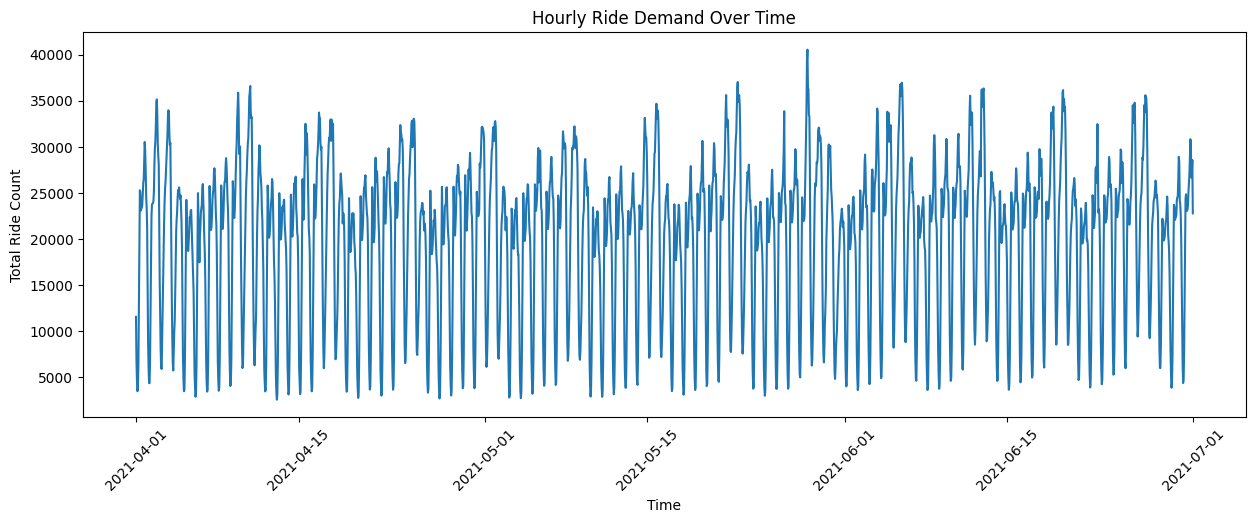

In [7]:
import matplotlib.pyplot as plt
total_hourly = (
    trip_df.groupby("pickup_hour")["ride_count"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,5))
plt.plot(total_hourly["pickup_hour"], total_hourly["ride_count"])
plt.xlabel("Time")
plt.ylabel("Total Ride Count")
plt.title("Hourly Ride Demand Over Time")
plt.xticks(rotation=45)
plt.show()

In [67]:
print(total_hourly.shape)
print(total_hourly.head())

(2184, 2)
          pickup_hour  ride_count
0 2021-04-01 00:00:00       11564
1 2021-04-01 01:00:00        6692
2 2021-04-01 02:00:00        4627
3 2021-04-01 03:00:00        3497
4 2021-04-01 04:00:00        3913


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd

base_path = "/content/drive/MyDrive/RideDemandForecast"

april = pd.read_parquet(f"{base_path}/hourly_demand_04.parquet")
may = pd.read_parquet(f"{base_path}/hourly_demand_05.parquet")
june = pd.read_parquet(f"{base_path}/hourly_demand_06.parquet")

trip_df = pd.concat(
    [april, may, june],
    ignore_index=True
)

print(trip_df.shape)

(550297, 3)


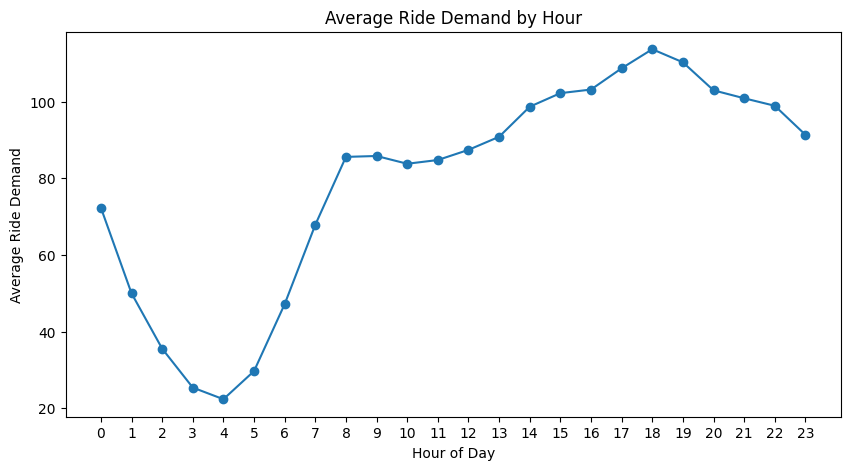

In [10]:
import matplotlib.pyplot as plt

hourly_avg = (
    trip_df.assign(hour=trip_df["pickup_hour"].dt.hour)
    .groupby("hour")["ride_count"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Average Ride Demand")
plt.title("Average Ride Demand by Hour")
plt.xticks(range(24))
plt.show()

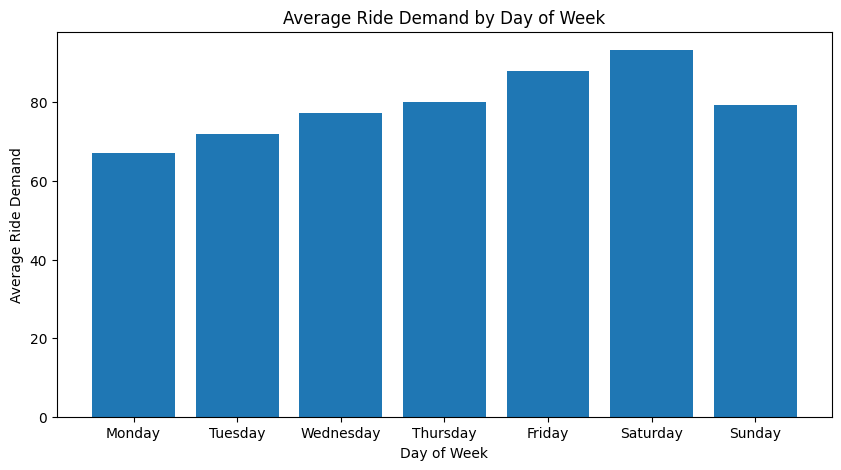

In [11]:
day_avg = (
    trip_df.assign(day_of_week=trip_df["pickup_hour"].dt.dayofweek)
    .groupby("day_of_week")["ride_count"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.bar(day_avg.index, day_avg.values)

plt.xlabel("Day of Week")
plt.ylabel("Average Ride Demand")
plt.title("Average Ride Demand by Day of Week")

plt.xticks(
    range(7),
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"]
)

plt.show()

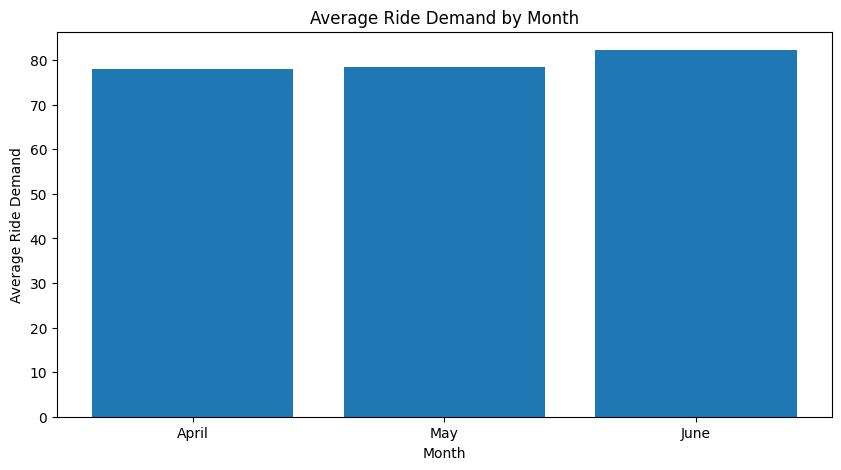

In [12]:
month_avg = (
    trip_df.assign(month=trip_df["pickup_hour"].dt.month)
    .groupby("month")["ride_count"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.bar(month_avg.index, month_avg.values)

plt.xlabel("Month")
plt.ylabel("Average Ride Demand")
plt.title("Average Ride Demand by Month")

plt.xticks(month_avg.index, ["April", "May", "June"])

plt.show()

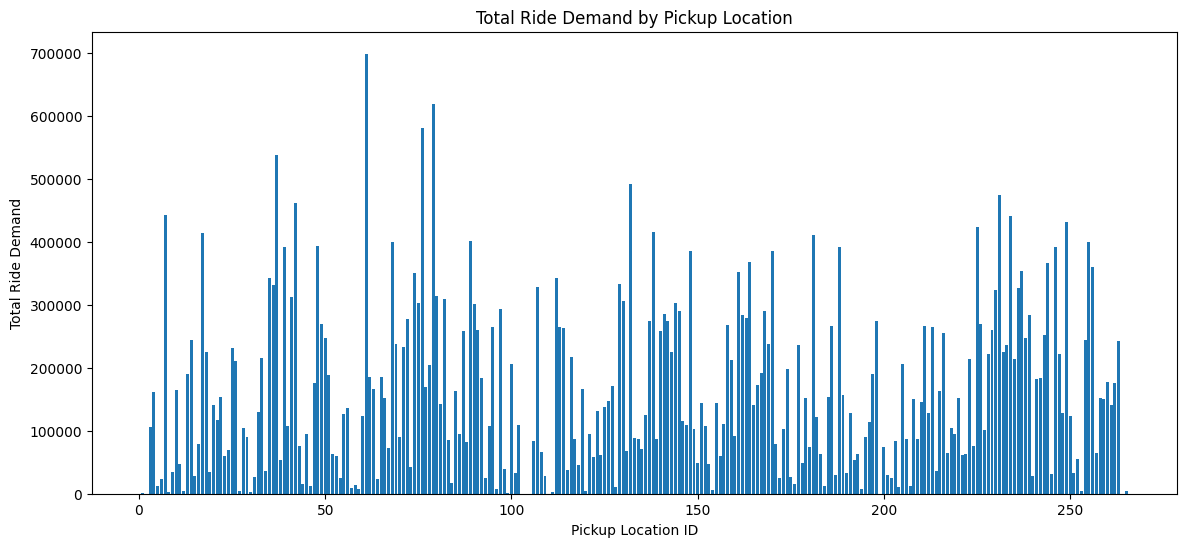

In [13]:
location_demand = (
    trip_df.groupby("PULocationID")["ride_count"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))
plt.bar(location_demand.index, location_demand.values)

plt.xlabel("Pickup Location ID")
plt.ylabel("Total Ride Demand")
plt.title("Total Ride Demand by Pickup Location")

plt.show()

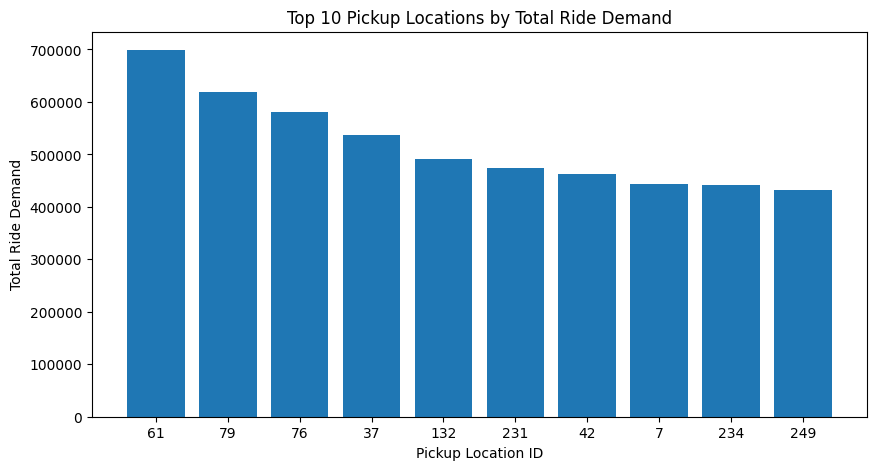

In [14]:
top_10_locations = (
    trip_df.groupby("PULocationID")["ride_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(
    top_10_locations.index.astype(str),
    top_10_locations.values
)

plt.xlabel("Pickup Location ID")
plt.ylabel("Total Ride Demand")
plt.title("Top 10 Pickup Locations by Total Ride Demand")

plt.show()

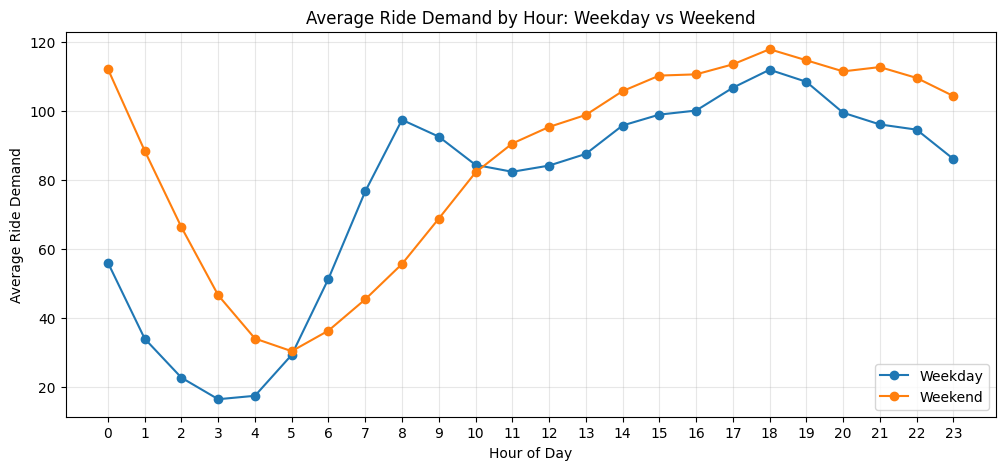

In [15]:
trip_df["hour"] = trip_df["pickup_hour"].dt.hour
trip_df["is_weekend"] = trip_df["pickup_hour"].dt.dayofweek >= 5

hour_weekend = (
    trip_df.groupby(["is_weekend", "hour"])["ride_count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

for weekend, data in hour_weekend.groupby("is_weekend"):
    label = "Weekend" if weekend else "Weekday"
    plt.plot(data["hour"], data["ride_count"], marker="o", label=label)

plt.xlabel("Hour of Day")
plt.ylabel("Average Ride Demand")
plt.title("Average Ride Demand by Hour: Weekday vs Weekend")
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Weather and Zone Data EDA

In [6]:
weather_df = pd.read_parquet(
    f"{base_path}/weather_cleaned.parquet"
)

print("Shape:", weather_df.shape)
print("Columns:", weather_df.columns.tolist())

weather_df.head()

weather_df.info()

weather_df.describe()

Shape: (365, 19)
Columns: ['datetime', 'temp', 'feelslike', 'humidity', 'precip', 'precipprob', 'snow', 'windgust', 'windspeed', 'sealevelpressure', 'cloudcover', 'visibility', 'day', 'month', 'dayofweek', 'weekofyear', 'is_weekend', 'quarter', 'dayofyear']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          365 non-null    datetime64[ns]
 1   temp              365 non-null    float64       
 2   feelslike         365 non-null    float64       
 3   humidity          365 non-null    float64       
 4   precip            365 non-null    float64       
 5   precipprob        365 non-null    int64         
 6   snow              365 non-null    float64       
 7   windgust          365 non-null    float64       
 8   windspeed         365 non-null    float64       
 9   sealevelpressure  365 non-null    floa

,datetime,temp,feelslike,humidity,precip,precipprob,snow,windgust,windspeed,sealevelpressure,cloudcover,visibility,day,month,dayofweek,weekofyear,is_weekend,quarter,dayofyear
count,365,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2021-07-02 00:00:00,14.075342,13.102740,60.248219,3.866247,41.643836,0.326849,43.914521,21.225753,1016.488219,53.605479,14.809041,15.720548,6.526027,3.002740,26.578082,0.284932,2.509589,183.000000
min,2021-01-01 00:00:00,-6.200000,-14.100000,22.600000,0.000000,0.000000,0.000000,25.900000,8.000000,996.900000,1.500000,1.200000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000
25%,2021-04-02 00:00:00,6.200000,4.100000,49.500000,0.000000,0.000000,0.000000,37.100000,16.000000,1012.200000,28.800000,14.300000,8.000000,4.000000,1.000000,14.000000,0.000000,2.000000,92.000000
50%,2021-07-02 00:00:00,14.300000,14.300000,61.200000,0.000000,0.000000,0.000000,42.500000,20.700000,1016.200000,52.900000,16.000000,16.000000,7.000000,3.000000,27.000000,0.000000,3.000000,183.000000
75%,2021-10-01 00:00:00,22.100000,22.100000,71.600000,1.990000,100.000000,0.000000,48.600000,24.900000,1021.100000,78.700000,16.000000,23.000000,10.000000,5.000000,40.000000,1.000000,4.000000,274.000000
max,2021-12-31 00:00:00,31.200000,33.600000,93.000000,165.380000,100.000000,16.100000,94.300000,50.000000,1034.100000,100.000000,16.000000,31.000000,12.000000,6.000000,53.000000,1.000000,4.000000,365.000000
std,NaN,9.185703,10.788292,15.441911,12.701193,49.364469,1.489115,10.913344,7.118541,6.723335,27.942289,2.093108,8.808321,3.452584,2.000685,15.081739,0.452001,1.118300,105.510663


In [17]:
zone_df = pd.read_csv(
    f"{base_path}/taxi_zone_lookup.csv"
)

print("Shape:", zone_df.shape)
print("Columns:", zone_df.columns.tolist())

zone_df.head()

zone_df.info()

Shape: (265, 4)
Columns: ['LocationID', 'Borough', 'Zone', 'service_zone']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   LocationID    265 non-null    int64 
 1   Borough       265 non-null    object
 2   Zone          264 non-null    object
 3   service_zone  263 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.4+ KB


In [18]:
trip_df.head()

trip_df.columns.tolist()

['pickup_hour', 'PULocationID', 'ride_count', 'hour', 'is_weekend']

In [19]:
print("WEATHER COLUMNS")
print(weather_df.columns.tolist())

WEATHER COLUMNS
['datetime', 'temp', 'feelslike', 'humidity', 'precip', 'precipprob', 'snow', 'windgust', 'windspeed', 'sealevelpressure', 'cloudcover', 'visibility', 'day', 'month', 'dayofweek', 'weekofyear', 'is_weekend', 'quarter', 'dayofyear']


In [20]:
print("RIDE COLUMNS")
print(trip_df.columns.tolist())

RIDE COLUMNS
['pickup_hour', 'PULocationID', 'ride_count', 'hour', 'is_weekend']


In [21]:
print("ZONE COLUMNS")
print(zone_df.columns.tolist())

ZONE COLUMNS
['LocationID', 'Borough', 'Zone', 'service_zone']


In [22]:
# Convert timestamp columns to datetime
trip_df["pickup_hour"] = pd.to_datetime(trip_df["pickup_hour"])
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])

print(trip_df["pickup_hour"].dtype)
print(weather_df["datetime"].dtype)

datetime64[us]
datetime64[ns]


In [23]:
print("Ride data:")
print(trip_df["pickup_hour"].min())
print(trip_df["pickup_hour"].max())

print("\nWeather data:")
print(weather_df["datetime"].min())
print(weather_df["datetime"].max())

Ride data:
2021-04-01 00:00:00
2021-06-30 23:00:00

Weather data:
2021-01-01 00:00:00
2021-12-31 00:00:00


In [24]:
ride_weather_df = trip_df.merge(
    weather_df,
    left_on="pickup_hour",
    right_on="datetime",
    how="left"
)

print("Shape:", ride_weather_df.shape)

ride_weather_df.head()

Shape: (550297, 24)


,pickup_hour,PULocationID,ride_count,hour,is_weekend_x,datetime,temp,feelslike,humidity,precip,...,sealevelpressure,cloudcover,visibility,day,month,dayofweek,weekofyear,is_weekend_y,quarter,dayofyear
0,2021-04-01,3,26,0,False,2021-04-01,8.1,5.4,62.5,1.99,...,1010.3,94.7,14.6,1.0,4.0,3.0,13.0,0.0,2.0,91.0
1,2021-04-01,4,24,0,False,2021-04-01,8.1,5.4,62.5,1.99,...,1010.3,94.7,14.6,1.0,4.0,3.0,13.0,0.0,2.0,91.0
2,2021-04-01,6,5,0,False,2021-04-01,8.1,5.4,62.5,1.99,...,1010.3,94.7,14.6,1.0,4.0,3.0,13.0,0.0,2.0,91.0
3,2021-04-01,7,83,0,False,2021-04-01,8.1,5.4,62.5,1.99,...,1010.3,94.7,14.6,1.0,4.0,3.0,13.0,0.0,2.0,91.0
4,2021-04-01,9,6,0,False,2021-04-01,8.1,5.4,62.5,1.99,...,1010.3,94.7,14.6,1.0,4.0,3.0,13.0,0.0,2.0,91.0


In [25]:
ride_weather_df.isnull().sum()

,0
pickup_hour,0
PULocationID,0
ride_count,0
hour,0
is_weekend_x,0
datetime,527426
temp,527426
feelslike,527426
humidity,527426
precip,527426


In [26]:
print("RIDE DATA")
print(trip_df["pickup_hour"].head(10))
print(trip_df["pickup_hour"].dtype)

print("\nWEATHER DATA")
print(weather_df["datetime"].head(10))
print(weather_df["datetime"].dtype)

RIDE DATA
0   2021-04-01
1   2021-04-01
2   2021-04-01
3   2021-04-01
4   2021-04-01
5   2021-04-01
6   2021-04-01
7   2021-04-01
8   2021-04-01
9   2021-04-01
Name: pickup_hour, dtype: datetime64[us]
datetime64[us]

WEATHER DATA
0   2021-01-01
1   2021-01-02
2   2021-01-03
3   2021-01-04
4   2021-01-05
5   2021-01-06
6   2021-01-07
7   2021-01-08
8   2021-01-09
9   2021-01-10
Name: datetime, dtype: datetime64[ns]
datetime64[ns]


In [27]:
print("Unique ride hours:", trip_df["pickup_hour"].nunique())
print("Unique weather timestamps:", weather_df["datetime"].nunique())

print("\nFirst 20 weather timestamps:")
print(weather_df["datetime"].head(20).tolist())

Unique ride hours: 2184
Unique weather timestamps: 365

First 20 weather timestamps:
[Timestamp('2021-01-01 00:00:00'), Timestamp('2021-01-02 00:00:00'), Timestamp('2021-01-03 00:00:00'), Timestamp('2021-01-04 00:00:00'), Timestamp('2021-01-05 00:00:00'), Timestamp('2021-01-06 00:00:00'), Timestamp('2021-01-07 00:00:00'), Timestamp('2021-01-08 00:00:00'), Timestamp('2021-01-09 00:00:00'), Timestamp('2021-01-10 00:00:00'), Timestamp('2021-01-11 00:00:00'), Timestamp('2021-01-12 00:00:00'), Timestamp('2021-01-13 00:00:00'), Timestamp('2021-01-14 00:00:00'), Timestamp('2021-01-15 00:00:00'), Timestamp('2021-01-16 00:00:00'), Timestamp('2021-01-17 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timestamp('2021-01-19 00:00:00'), Timestamp('2021-01-20 00:00:00')]


In [28]:
print("Ride sample:")
print(trip_df[["pickup_hour", "PULocationID", "ride_count"]].head())

print("\nWeather sample:")
print(weather_df[["datetime", "temp", "humidity", "precip"]].head())

Ride sample:
  pickup_hour  PULocationID  ride_count
0  2021-04-01             3          26
1  2021-04-01             4          24
2  2021-04-01             6           5
3  2021-04-01             7          83
4  2021-04-01             9           6

Weather sample:
    datetime  temp  humidity  precip
0 2021-01-01   2.5      67.8   15.33
1 2021-01-02   5.8      74.0    2.38
2 2021-01-03   2.5      80.7    5.09
3 2021-01-04   3.6      76.6    0.84
4 2021-01-05   3.8      68.7    0.00


In [29]:
print(trip_df.shape)
print(weather_df.shape)
print(zone_df.shape)



(550297, 5)
(365, 19)
(265, 4)


In [7]:
trip_df["pickup_date"] = trip_df["pickup_hour"].dt.normalize()

trip_df[["pickup_hour", "pickup_date"]].head(10)

,pickup_hour,pickup_date
0,2021-04-01,2021-04-01
1,2021-04-01,2021-04-01
2,2021-04-01,2021-04-01
3,2021-04-01,2021-04-01
4,2021-04-01,2021-04-01
5,2021-04-01,2021-04-01
6,2021-04-01,2021-04-01
7,2021-04-01,2021-04-01
8,2021-04-01,2021-04-01
9,2021-04-01,2021-04-01


In [8]:
weather_df["weather_date"] = weather_df["datetime"].dt.normalize()

weather_df[["datetime", "weather_date"]].head()

,datetime,weather_date
0,2021-01-01,2021-01-01
1,2021-01-02,2021-01-02
2,2021-01-03,2021-01-03
3,2021-01-04,2021-01-04
4,2021-01-05,2021-01-05


In [9]:
print("Ride dates:")
print(trip_df["pickup_date"].min())
print(trip_df["pickup_date"].max())

print("\nWeather dates:")
print(weather_df["weather_date"].min())
print(weather_df["weather_date"].max())

Ride dates:
2021-04-01 00:00:00
2021-06-30 00:00:00

Weather dates:
2021-01-01 00:00:00
2021-12-31 00:00:00


In [33]:
ride_weather_df = trip_df.merge(
    weather_df,
    left_on="pickup_date",
    right_on="weather_date",
    how="left"
)

print("Shape:", ride_weather_df.shape)
ride_weather_df.head()


ride_weather_df.isnull().sum()

Shape: (550297, 26)


,0
pickup_hour,0
PULocationID,0
ride_count,0
hour,0
is_weekend_x,0
pickup_date,0
datetime,0
temp,0
feelslike,0
humidity,0


In [34]:
ride_weather_df.isnull().sum()

,0
pickup_hour,0
PULocationID,0
ride_count,0
hour,0
is_weekend_x,0
pickup_date,0
datetime,0
temp,0
feelslike,0
humidity,0


In [35]:
combined_df = ride_weather_df.merge(
    zone_df,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

print("Shape:", combined_df.shape)
combined_df.head()

Shape: (550297, 30)


,pickup_hour,PULocationID,ride_count,hour,is_weekend_x,pickup_date,datetime,temp,feelslike,humidity,...,dayofweek,weekofyear,is_weekend_y,quarter,dayofyear,weather_date,LocationID,Borough,Zone,service_zone
0,2021-04-01,3,26,0,False,2021-04-01,2021-04-01,8.1,5.4,62.5,...,3,13,0,2,91,2021-04-01,3,Bronx,Allerton/Pelham Gardens,Boro Zone
1,2021-04-01,4,24,0,False,2021-04-01,2021-04-01,8.1,5.4,62.5,...,3,13,0,2,91,2021-04-01,4,Manhattan,Alphabet City,Yellow Zone
2,2021-04-01,6,5,0,False,2021-04-01,2021-04-01,8.1,5.4,62.5,...,3,13,0,2,91,2021-04-01,6,Staten Island,Arrochar/Fort Wadsworth,Boro Zone
3,2021-04-01,7,83,0,False,2021-04-01,2021-04-01,8.1,5.4,62.5,...,3,13,0,2,91,2021-04-01,7,Queens,Astoria,Boro Zone
4,2021-04-01,9,6,0,False,2021-04-01,2021-04-01,8.1,5.4,62.5,...,3,13,0,2,91,2021-04-01,9,Queens,Auburndale,Boro Zone


In [36]:
print("Missing Borough:",
      combined_df["Borough"].isna().sum())

print("Missing Zone:",
      combined_df["Zone"].isna().sum())

print("Missing service_zone:",
      combined_df["service_zone"].isna().sum())

Missing Borough: 0
Missing Zone: 1582
Missing service_zone: 1584


In [37]:
missing_zones = combined_df[
    combined_df["Zone"].isna() |
    combined_df["service_zone"].isna()
]

print("Rows with missing zone information:", len(missing_zones))

print(
    missing_zones[
        ["PULocationID", "Borough", "Zone", "service_zone"]
    ].drop_duplicates()
)

Rows with missing zone information: 1584
        PULocationID  Borough Zone service_zone
250              265  Unknown  NaN          NaN
547996           264  Unknown   NV          NaN


In [38]:
print(
    missing_zones["PULocationID"]
    .value_counts()
)

PULocationID
265    1582
264       2
Name: count, dtype: int64


In [39]:
zone_df[
    zone_df["LocationID"].isin(
        missing_zones["PULocationID"].unique()
    )
]

,LocationID,Borough,Zone,service_zone
263,264,Unknown,NV,NaN
264,265,Unknown,NaN,NaN


In [40]:
combined_df["Zone"] = combined_df["Zone"].fillna("Unknown")
combined_df["service_zone"] = combined_df["service_zone"].fillna("Unknown")

print("Missing Borough:", combined_df["Borough"].isna().sum())
print("Missing Zone:", combined_df["Zone"].isna().sum())
print("Missing service_zone:", combined_df["service_zone"].isna().sum())

print("Missing Borough:", combined_df["Borough"].isna().sum())
print("Missing Zone:", combined_df["Zone"].isna().sum())
print("Missing service_zone:", combined_df["service_zone"].isna().sum())

combined_df[[
    "pickup_hour",
    "PULocationID",
    "ride_count",
    "temp",
    "humidity",
    "precip",
    "Borough",
    "Zone",
    "service_zone"
]].head(10)


print(combined_df.shape)

Missing Borough: 0
Missing Zone: 0
Missing service_zone: 0
Missing Borough: 0
Missing Zone: 0
Missing service_zone: 0
(550297, 30)


In [41]:
zone_df["LocationID"].duplicated().sum()

zone_df[
    zone_df["LocationID"].duplicated(keep=False)
].sort_values("LocationID")

print("Ride rows:", len(trip_df))
print("After weather merge:", len(ride_weather_df))
print("After zone merge:", len(combined_df))

Ride rows: 550297
After weather merge: 550297
After zone merge: 550297


In [42]:
print("trip_df:", trip_df.shape)

trip_df: (550297, 6)


In [43]:
print("weather_df:", weather_df.shape)

weather_df: (365, 20)


In [44]:
print("ride_weather_df:", ride_weather_df.shape)

ride_weather_df: (550297, 26)


In [45]:
print("zone_df:", zone_df.shape)

zone_df: (265, 4)


In [46]:
print("Duplicate LocationIDs:",
      zone_df["LocationID"].duplicated().sum())

Duplicate LocationIDs: 0


In [47]:
columns_to_drop = [
    col for col in ["datetime", "weather_date", "LocationID"]
    if col in combined_df.columns
]

combined_df = combined_df.drop(columns=columns_to_drop)

print("Dropped:", columns_to_drop)
print("Shape:", combined_df.shape)
print(combined_df.columns.tolist())




Dropped: ['datetime', 'weather_date', 'LocationID']
Shape: (550297, 27)
['pickup_hour', 'PULocationID', 'ride_count', 'hour', 'is_weekend_x', 'pickup_date', 'temp', 'feelslike', 'humidity', 'precip', 'precipprob', 'snow', 'windgust', 'windspeed', 'sealevelpressure', 'cloudcover', 'visibility', 'day', 'month', 'dayofweek', 'weekofyear', 'is_weekend_y', 'quarter', 'dayofyear', 'Borough', 'Zone', 'service_zone']


In [48]:
combined_df.head()

,pickup_hour,PULocationID,ride_count,hour,is_weekend_x,pickup_date,temp,feelslike,humidity,precip,...,day,month,dayofweek,weekofyear,is_weekend_y,quarter,dayofyear,Borough,Zone,service_zone
0,2021-04-01,3,26,0,False,2021-04-01,8.1,5.4,62.5,1.99,...,1,4,3,13,0,2,91,Bronx,Allerton/Pelham Gardens,Boro Zone
1,2021-04-01,4,24,0,False,2021-04-01,8.1,5.4,62.5,1.99,...,1,4,3,13,0,2,91,Manhattan,Alphabet City,Yellow Zone
2,2021-04-01,6,5,0,False,2021-04-01,8.1,5.4,62.5,1.99,...,1,4,3,13,0,2,91,Staten Island,Arrochar/Fort Wadsworth,Boro Zone
3,2021-04-01,7,83,0,False,2021-04-01,8.1,5.4,62.5,1.99,...,1,4,3,13,0,2,91,Queens,Astoria,Boro Zone
4,2021-04-01,9,6,0,False,2021-04-01,8.1,5.4,62.5,1.99,...,1,4,3,13,0,2,91,Queens,Auburndale,Boro Zone


## Weather Data EDA


In [49]:
daily_weather = weather_df[
    (weather_df["datetime"] >= "2021-04-01") &
    (weather_df["datetime"] <= "2021-06-30")
].copy()

print("Weather rows:", len(daily_weather))
print("Start date:", daily_weather["datetime"].min())
print("End date:", daily_weather["datetime"].max())

Weather rows: 91
Start date: 2021-04-01 00:00:00
End date: 2021-06-30 00:00:00


In [50]:
daily_weather[[
    "datetime",
    "temp",
    "feelslike",
    "humidity",
    "precip",
    "windspeed",
    "cloudcover"
]].head(10)

,datetime,temp,feelslike,humidity,precip,windspeed,cloudcover
90,2021-04-01,8.1,5.4,62.5,1.99,36.8,94.7
91,2021-04-02,1.6,-3.3,39.6,0.00,31.0,70.4
92,2021-04-03,5.6,3.3,27.6,0.00,17.4,12.9
93,2021-04-04,11.9,11.5,33.0,0.00,17.2,59.9
94,2021-04-05,14.2,13.8,27.2,0.00,33.8,9.4
95,2021-04-06,14.4,13.9,22.6,0.00,24.9,12.2
96,2021-04-07,14.9,14.9,36.8,0.00,12.0,30.1
97,2021-04-08,14.3,14.3,52.2,0.00,15.9,11.8
98,2021-04-09,10.9,10.7,75.0,0.23,16.9,60.0
99,2021-04-10,14.3,14.3,74.1,0.19,14.2,75.6


In [51]:
print("trip_df exists:", 'trip_df' in globals())
print("weather_df exists:", 'weather_df' in globals())
print("zone_df exists:", 'zone_df' in globals())
print("combined_df exists:", 'combined_df' in globals())

trip_df exists: True
weather_df exists: True
zone_df exists: True
combined_df exists: True


In [52]:
import pandas as pd
import os

base_path = '/content/drive/MyDrive/RideDemandForecast'

ride_apr = pd.read_parquet(
    os.path.join(base_path, 'hourly_demand_04.parquet')
)

ride_may = pd.read_parquet(
    os.path.join(base_path, 'hourly_demand_05.parquet')
)

ride_jun = pd.read_parquet(
    os.path.join(base_path, 'hourly_demand_06.parquet')
)

print("April:", ride_apr.shape)
print("May:", ride_may.shape)
print("June:", ride_jun.shape)

April: (181057, 3)
May: (187381, 3)
June: (181859, 3)


In [53]:
trip_df = pd.concat(
    [ride_apr, ride_may, ride_jun],
    ignore_index=True
)

print("Trip data shape:", trip_df.shape)
print(trip_df.columns.tolist())
trip_df.head()

Trip data shape: (550297, 3)
['pickup_hour', 'PULocationID', 'ride_count']


,pickup_hour,PULocationID,ride_count
0,2021-04-01,3,26
1,2021-04-01,4,24
2,2021-04-01,6,5
3,2021-04-01,7,83
4,2021-04-01,9,6


In [54]:
combined_df = ride_weather_df.merge(
    zone_df,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

print("Before zone merge:", ride_weather_df.shape)
print("After zone merge:", combined_df.shape)

Before zone merge: (550297, 26)
After zone merge: (550297, 30)


In [55]:
print("Missing Borough:", combined_df["Borough"].isna().sum())
print("Missing Zone:", combined_df["Zone"].isna().sum())
print("Missing service_zone:", combined_df["service_zone"].isna().sum())

Missing Borough: 0
Missing Zone: 1582
Missing service_zone: 1584


In [56]:
# Fix LocationID 264
combined_df.loc[
    combined_df["PULocationID"] == 264,
    "service_zone"
] = "NV"

# Fix LocationID 265
combined_df.loc[
    combined_df["PULocationID"] == 265,
    ["Zone", "service_zone"]
] = ["Unknown", "Unknown"]

# Check again
print("Missing Borough:", combined_df["Borough"].isna().sum())
print("Missing Zone:", combined_df["Zone"].isna().sum())
print("Missing service_zone:", combined_df["service_zone"].isna().sum())

Missing Borough: 0
Missing Zone: 0
Missing service_zone: 0


In [57]:
print("Final shape:", combined_df.shape)
print(combined_df.columns.tolist())

Final shape: (550297, 30)
['pickup_hour', 'PULocationID', 'ride_count', 'hour', 'is_weekend_x', 'pickup_date', 'datetime', 'temp', 'feelslike', 'humidity', 'precip', 'precipprob', 'snow', 'windgust', 'windspeed', 'sealevelpressure', 'cloudcover', 'visibility', 'day', 'month', 'dayofweek', 'weekofyear', 'is_weekend_y', 'quarter', 'dayofyear', 'weather_date', 'LocationID', 'Borough', 'Zone', 'service_zone']


In [58]:
daily_weather = weather_df[
    (weather_df["datetime"] >= "2021-04-01") &
    (weather_df["datetime"] <= "2021-06-30")
].copy()

print("Weather rows:", len(daily_weather))
print("Start:", daily_weather["datetime"].min())
print("End:", daily_weather["datetime"].max())

Weather rows: 91
Start: 2021-04-01 00:00:00
End: 2021-06-30 00:00:00


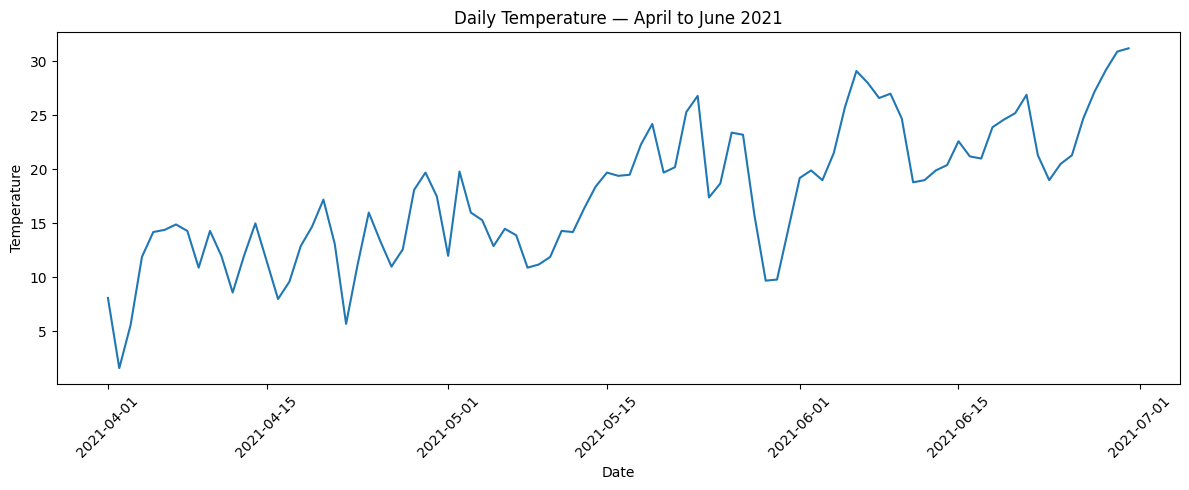

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    daily_weather["datetime"],
    daily_weather["temp"]
)

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Daily Temperature — April to June 2021")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

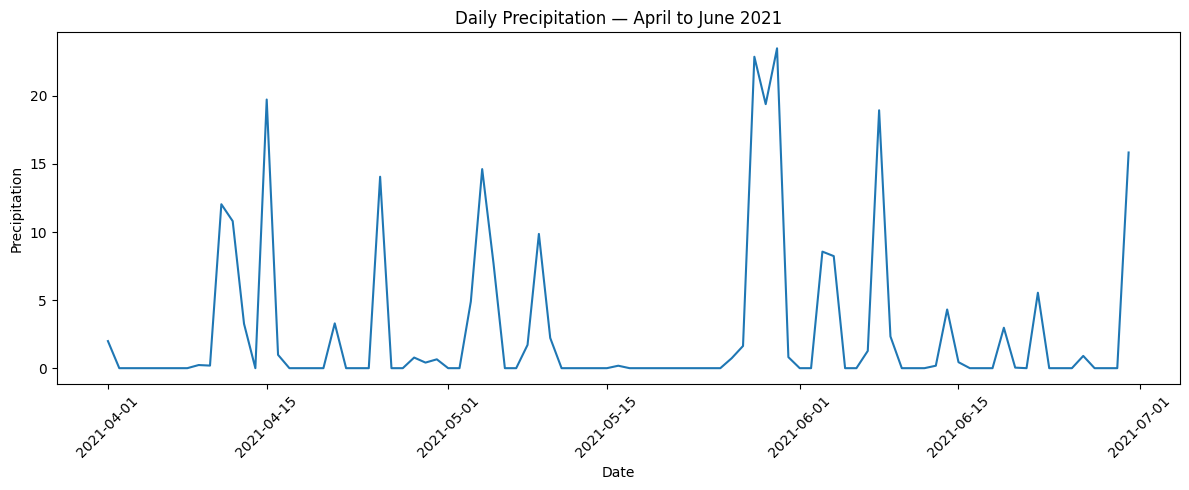

In [60]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_weather["datetime"],
    daily_weather["precip"]
)

plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("Daily Precipitation — April to June 2021")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

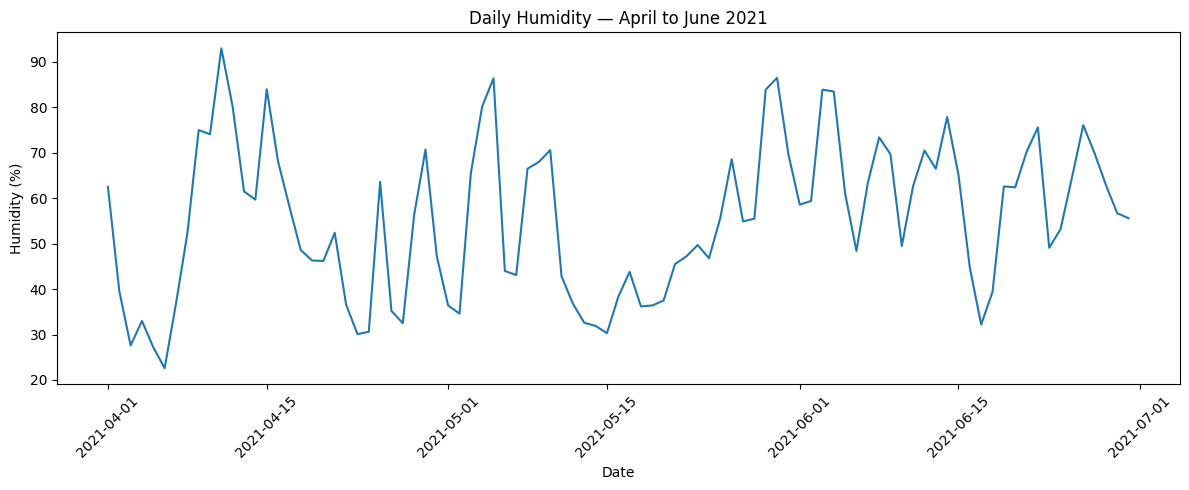

In [61]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_weather["datetime"],
    daily_weather["humidity"]
)

plt.xlabel("Date")
plt.ylabel("Humidity (%)")
plt.title("Daily Humidity — April to June 2021")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

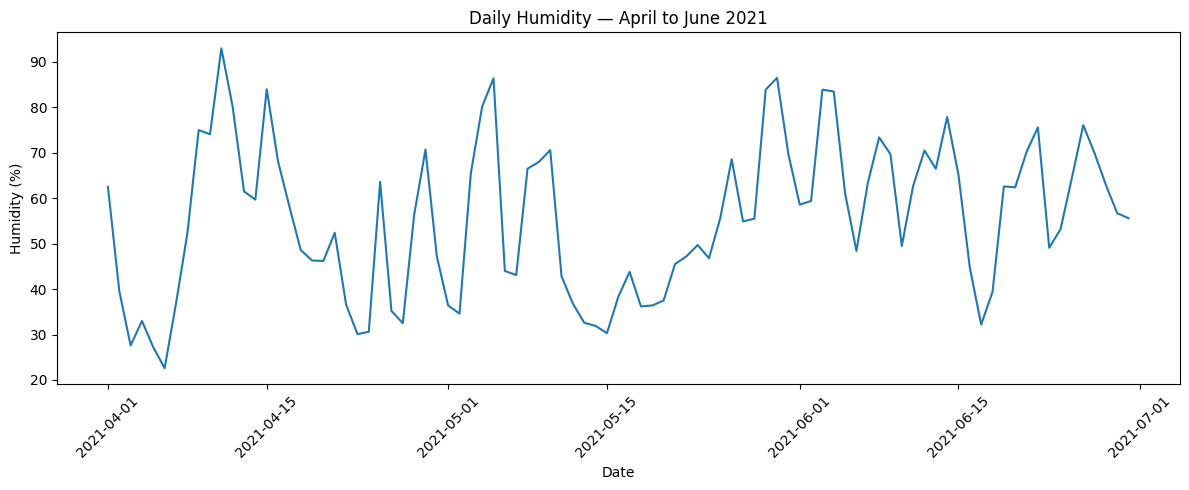

In [62]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_weather["datetime"],
    daily_weather["humidity"]
)

plt.xlabel("Date")
plt.ylabel("Humidity (%)")
plt.title("Daily Humidity — April to June 2021")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
print(trip_df.shape)
print(trip_df.columns.tolist())

(550297, 3)
['pickup_hour', 'PULocationID', 'ride_count']


In [66]:
daily_rides = (
    trip_df
    .groupby("pickup_date", as_index=False)["ride_count"]
    .sum()
)

print(daily_rides.shape)
print(daily_rides.head())

KeyError: 'pickup_date'

In [ ]:
daily_rides_weather = daily_rides.merge(
    daily_weather,
    left_on="pickup_date",
    right_on="datetime",
    how="left"
)

print("Shape:", daily_rides_weather.shape)
print(daily_rides_weather.head())

In [ ]:
print("Missing values:")
print(
    daily_rides_weather[
        ["ride_count", "temp", "humidity", "precip"]
    ].isna().sum()
)

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    daily_rides_weather["temp"],
    daily_rides_weather["ride_count"]
)

plt.xlabel("Temperature")
plt.ylabel("Daily Ride Demand")
plt.title("Ride Demand vs Temperature — April to June 2021")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    daily_rides_weather["precip"],
    daily_rides_weather["ride_count"]
)

plt.xlabel("Precipitation")
plt.ylabel("Daily Ride Demand")
plt.title("Ride Demand vs Precipitation — April to June 2021")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    daily_rides_weather["humidity"],
    daily_rides_weather["ride_count"]
)

plt.xlabel("Humidity (%)")
plt.ylabel("Daily Ride Demand")
plt.title("Ride Demand vs Humidity — April to June 2021")

plt.tight_layout()
plt.show()

In [ ]:
zone_demand = (
    combined_df
    .groupby(
        ["PULocationID", "Borough", "Zone", "service_zone"],
        as_index=False
    )["ride_count"]
    .sum()
)

print("Shape:", zone_demand.shape)
print(zone_demand.head())

In [ ]:
top_zones = (
    zone_demand
    .sort_values("ride_count", ascending=False)
    .head(10)
)

print(top_zones[[
    "PULocationID",
    "Borough",
    "Zone",
    "ride_count"
]])

In [ ]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_zones["Zone"][::-1],
    top_zones["ride_count"][::-1]
)

plt.xlabel("Total Ride Demand")
plt.ylabel("Pickup Zone")
plt.title("Top 10 Pickup Zones by Ride Demand — April to June 2021")

plt.tight_layout()
plt.show()

In [ ]:
borough_demand = (
    combined_df
    .groupby("Borough", as_index=False)["ride_count"]
    .sum()
    .sort_values("ride_count", ascending=False)
)

print(borough_demand)

In [ ]:
borough_plot = borough_demand[
    ~borough_demand["Borough"].isin(["Unknown", "EWR"])
]

plt.figure(figsize=(10, 6))

plt.bar(
    borough_plot["Borough"],
    borough_plot["ride_count"]
)

plt.xlabel("Borough")
plt.ylabel("Total Ride Demand")
plt.title("Ride Demand by Borough — April to June 2021")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# STEP 1: Prepare data for modeling
# ==========================================

model_df = combined_df.copy()

# Make sure pickup_date is datetime
model_df["pickup_date"] = pd.to_datetime(model_df["pickup_date"])

# Sort chronologically
model_df = model_df.sort_values(
    ["pickup_date", "pickup_hour", "PULocationID"]
).reset_index(drop=True)

# Check date range
print("Date range:")
print(model_df["pickup_date"].min(), "to", model_df["pickup_date"].max())

# Check shape
print("\nModel dataframe shape:")
print(model_df.shape)

# Show columns
print("\nColumns:")
print(model_df.columns.tolist())

# Check target variable
print("\nRide count statistics:")
print(model_df["ride_count"].describe())

NameError: name 'combined_df' is not defined

In [ ]:
# ==========================================
# STEP 2: Select features and target
# ==========================================

features = [
    "pickup_hour",
    "PULocationID",
    "temp",
    "feelslike",
    "humidity",
    "precip",
    "precipprob",
    "snow",
    "windgust",
    "windspeed",
    "sealevelpressure",
    "cloudcover",
    "visibility",
    "day",
    "month",
    "dayofweek",
    "weekofyear",
    "is_weekend",
    "quarter",
    "dayofyear"
]

X = model_df[features]
y = model_df["ride_count"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used:")
print(features)

print("\nMissing values in X:", X.isna().sum().sum())
print("Missing values in y:", y.isna().sum())

In [ ]:
# ==========================================
# STEP 3: Time-based train/test split
# ==========================================

train_mask = model_df["pickup_date"] < "2021-06-01"
test_mask = model_df["pickup_date"] >= "2021-06-01"

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining period:")
print(model_df.loc[train_mask, "pickup_date"].min(),
      "to",
      model_df.loc[train_mask, "pickup_date"].max())

print("\nTesting period:")
print(model_df.loc[test_mask, "pickup_date"].min(),
      "to",
      model_df.loc[test_mask, "pickup_date"].max())

In [ ]:
print(model_df.shape)
print(X.shape)
print(y.shape)